<a href="https://colab.research.google.com/github/purvatawade/Smart-Inventory-Sales-Optimizer/blob/main/retail_analytics_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
df = pd.read_csv('superstore.csv', encoding='utf-8')
df.columns = df.columns.str.replace(' ', '_').str.replace('-', '_').str.lower()
print(f"Workspace Ready! Total loaded records: {len(df)} rows.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Workspace Ready! Total loaded records: 10800 rows.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
category_counts = df.groupby('sub_category').size().sort_values(ascending=False)
print("--- TOP 5 HIGH-VOLUME SUB-CATEGORIES ---")
print(category_counts.head(5))

--- TOP 5 HIGH-VOLUME SUB-CATEGORIES ---
sub_category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
dtype: int64


In [ ]:
binders_df = df[df['sub_category'] == 'Binders'].copy()
timeline_df = binders_df.groupby('order_date')['quantity'].sum().reset_index()
timeline_df.columns=['ds', 'y']
timeline_df['ds'] = pd.to_datetime(timeline_df['ds'])
print("--- PROPHET-READY DATA FORMAT ---")
print(timeline_df.head())
print(f"\nSuccess! Total data points found for training: {len(timeline_df)} dates.")

--- PROPHET-READY DATA FORMAT ---
          ds     y
0 2018-01-01  21.0
1 2018-01-12   5.0
2 2015-01-13   5.0
3 2016-01-13   3.0
4 2018-01-14   7.0

Success! Total data points found for training: 776 dates.


In [ ]:
from prophet import Prophet
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(timeline_df)
future_dates = model.make_future_dataframe(periods=90, freq='D')
forecast = model.predict(future_dates)
print("--- METAPROPHET INVENTORY DEMAND FORECAST MATRIX ---")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

--- METAPROPHET INVENTORY DEMAND FORECAST MATRIX ---
            ds      yhat  yhat_lower  yhat_upper
861 2019-03-26  9.089415    1.064793   16.391346
862 2019-03-27  8.319857    0.681795   15.959288
863 2019-03-28  7.246747   -0.481079   14.806661
864 2019-03-29  8.867593    1.922490   16.611933
865 2019-03-30  9.624182    2.443513   17.017226


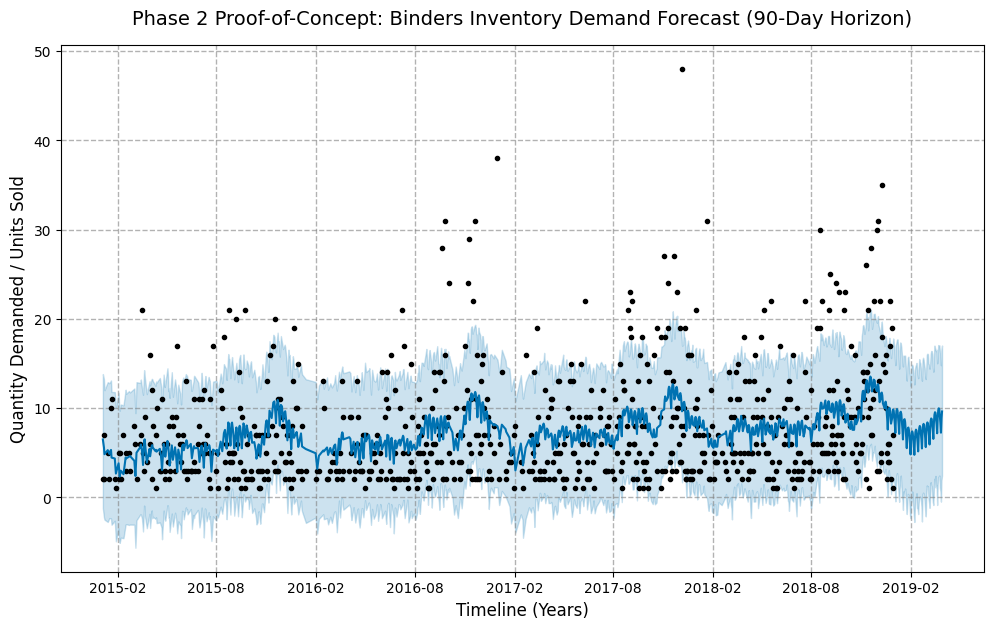

In [ ]:
import matplotlib.pyplot as plt
fig1 = model.plot(forecast)
plt.title("Phase 2 Proof-of-Concept: Binders Inventory Demand Forecast (90-Day Horizon)", fontsize=14, pad=15)
plt.xlabel("Timeline (Years)", fontsize=12)
plt.ylabel("Quantity Demanded / Units Sold", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [ ]:
print("--- RAW TRANSACTION CART STRUCTURE ---")
print(df[['order_id', 'sub_category', 'quantity']].head(10))

--- RAW TRANSACTION CART STRUCTURE ---
         order_id sub_category  quantity
0  CA-2017-152156    Bookcases       2.0
1  CA-2017-152156       Chairs       3.0
2  CA-2017-138688       Labels       2.0
3  US-2016-108966       Tables       5.0
4  US-2016-108966      Storage       2.0
5  CA-2015-115812  Furnishings       7.0
6  CA-2015-115812          Art       4.0
7  CA-2015-115812       Phones       6.0
8  CA-2015-115812      Binders       3.0
9  CA-2015-115812   Appliances       5.0


In [ ]:
baskets = df.groupby('order_id')['sub_category'].apply(list).reset_index()
basket_list = baskets['sub_category'].tolist()
print("--- CLEANED TRANSACTION BASKETS FOR FP-GROWTH ---")
for i, cart in enumerate(basket_list[:5]):
    print(f"Basket #{i+1}: {cart}")
print(f"\nTotal compiled shopping baskets ready for rule mining: {len(basket_list)}")

--- CLEANED TRANSACTION BASKETS FOR FP-GROWTH ---
Basket #1: ['Phones']
Basket #2: ['Tables', 'Binders']
Basket #3: ['Paper']
Basket #4: ['Binders']
Basket #5: ['Fasteners', 'Paper']

Total compiled shopping baskets ready for rule mining: 5015


In [13]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# 1. Drop any rows where sub_category is missing, and force everything to clean text strings
df_clean = df.dropna(subset=['sub_category']).copy()
df_clean['sub_category'] = df_clean['sub_category'].astype(str)

# 2. Re-compile the clean horizontal transaction baskets
baskets = df_clean.groupby('order_id')['sub_category'].apply(list).reset_index()
basket_list = baskets['sub_category'].tolist()

# 3. Run the One-Hot Transaction Encoder
te = TransactionEncoder()
te_ary = te.fit(basket_list).transform(basket_list)
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

# 4. Mine frequent patterns via FP-Growth (Minimum 1% support baseline)
frequent_itemsets = fpgrowth(basket_df, min_support=0.01, use_colnames=True)

# 5. Extract our associative product recommendations using Lift
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values(by="lift", ascending=False)

# Display the final clean cross-selling rule recommendations
print("--- SUCCESS! TOP 5 DISCOVERED RETAIL ASSOCIATION RULES ---")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

--- SUCCESS! TOP 5 DISCOVERED RETAIL ASSOCIATION RULES ---
         antecedents       consequents   support  confidence      lift
31         (Storage)  (Paper, Binders)  0.010581    0.068211  1.242434
30  (Paper, Binders)         (Storage)  0.010581    0.192727  1.242434
4   (Paper, Binders)          (Phones)  0.010781    0.196364  1.208336
5           (Phones)  (Paper, Binders)  0.010781    0.066339  1.208336
2    (Phones, Paper)         (Binders)  0.010781    0.308571  1.174494


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag